# Task 2 — Credit Risk Prediction

## Objective
Predict whether a loan applicant is likely to default / loan will be approved (based on dataset target).

## Dataset
Loan Prediction Dataset (Kaggle)

## What we will do
1. Load and inspect dataset  
2. Handle missing values properly  
3. Visualize key features (LoanAmount, Education, ApplicantIncome)  
4. Train a baseline classification model (Logistic Regression)  
5. Evaluate with Accuracy + Confusion Matrix (and a short report)

## Notes
- Put the CSV inside: `data/`
- Run cells from top to bottom (important).

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [5]:
DATA_PATH = Path("../data/loan-prediction.csv")  # <- change if your file name differs
TARGET_CANDIDATES = ["Loan_Status", "loan_status", "default", "Default", "TARGET", "target"]

TEST_SIZE = 0.20
RANDOM_STATE = 42

# Optional outputs
FIG_DIR = Path("../outputs/task2_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
def save_fig(filename: str) -> None:
    """Save current matplotlib figure safely."""
    try:
        out = FIG_DIR / filename
        plt.tight_layout()
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print("Saved:", out)
    except Exception as e:
        print("Note: figure not saved:", e)

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize column names to reduce issues across dataset versions."""
    def _norm(c: str) -> str:
        c = str(c).strip().lower()
        c = c.replace(" ", "_").replace("-", "_").replace(".", "_").replace("/", "_")
        c = c.replace("(", "").replace(")", "")
        return c
    df = df.copy()
    df.columns = [_norm(c) for c in df.columns]
    return df

def read_csv_safely(path: Path) -> pd.DataFrame:
    """
    Read CSV with automatic separator detection.
    Works for ',' and ';' common formats.
    """
    return pd.read_csv(path, sep=None, engine="python")

In [7]:
READY = True

if not DATA_PATH.exists():
    READY = False
    print(f"Dataset not found: {DATA_PATH.resolve()}")
    print("Fix: Put your CSV in data/ folder OR update DATA_PATH in the config cell.")
else:
    df_raw = read_csv_safely(DATA_PATH)
    df = normalize_columns(df_raw)

    print("Loaded from:", DATA_PATH)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head())

Loaded from: ..\data\loan-prediction.csv
Shape: (614, 13)
Columns: ['loan_id', 'gender', 'married', 'dependents', 'education', 'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount', 'loan_amount_term', 'credit_history', 'property_area', 'loan_status']


,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
if not READY:
    print("Skipping: dataset not loaded.")
else:
    target_col = None
    for cand in TARGET_CANDIDATES:
        cand_norm = cand.strip().lower()
        if cand_norm in df.columns:
            target_col = cand_norm
            break

    if target_col is None:
        READY = False
        print("Target column not found.")
        print("Available columns:", df.columns.tolist())
        print("Fix: set your target column name in TARGET_CANDIDATES (Config cell).")
    else:
        print("Selected target column:", target_col)
        print("Target unique values:", df[target_col].dropna().unique())

Selected target column: loan_status
Target unique values: ['Y' 'N']


In [9]:
if not READY:
    print("Skipping: target not ready.")
else:
    missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
    display(missing_pct[missing_pct > 0].to_frame("missing_%"))

    dup_count = df.duplicated().sum()
    print("Duplicate rows:", dup_count)

,missing_%
credit_history,8.14
self_employed,5.21
loanamount,3.58
dependents,2.44
loan_amount_term,2.28
gender,2.12
married,0.49


Duplicate rows: 0


## EDA (Required Visualizations)

We will visualize:
- **LoanAmount** distribution
- **ApplicantIncome** distribution
- **Education** vs target

Plots are built safely: if a column does not exist, the notebook will skip that plot (no crash).

Saved: ..\outputs\task2_figures\hist_loanamount.png


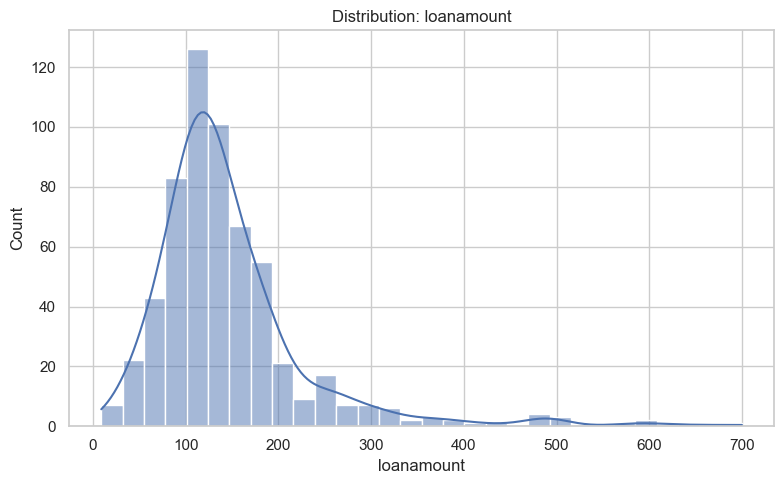

Saved: ..\outputs\task2_figures\hist_applicantincome.png


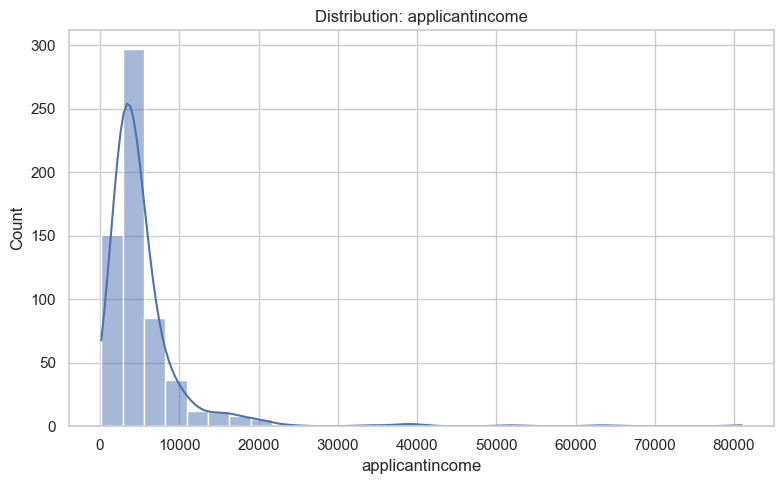

Saved: ..\outputs\task2_figures\count_education_by_loan_status.png


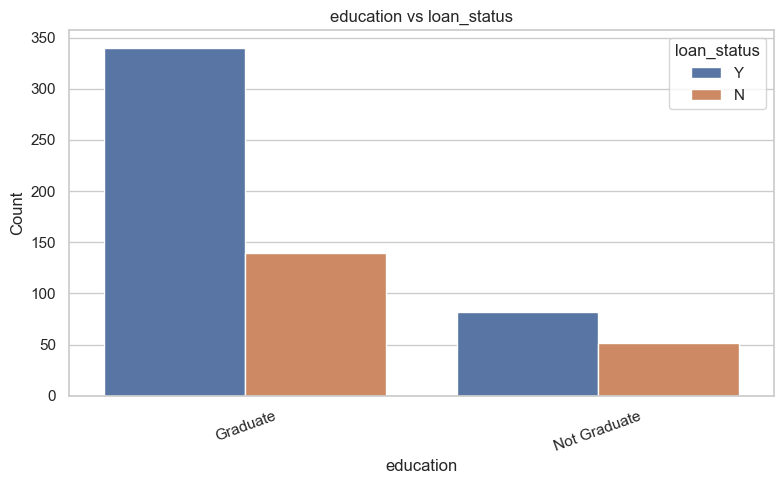

In [10]:
if not READY:
    print("Skipping EDA: dataset/target not ready.")
else:
    def safe_hist(col: str, bins: int = 30):
        if col in df.columns:
            ax = sns.histplot(df[col].dropna(), bins=bins, kde=True)
            ax.set_title(f"Distribution: {col}")
            ax.set_xlabel(col)
            ax.set_ylabel("Count")
            save_fig(f"hist_{col}.png")
            plt.show()
        else:
            print(f"Skipped histogram: column '{col}' not found.")

    def safe_count(col: str, hue: str):
        if col in df.columns and hue in df.columns:
            ax = sns.countplot(data=df, x=col, hue=hue)
            ax.set_title(f"{col} vs {hue}")
            ax.set_xlabel(col)
            ax.set_ylabel("Count")
            plt.xticks(rotation=20)
            save_fig(f"count_{col}_by_{hue}.png")
            plt.show()
        else:
            print(f"Skipped countplot: '{col}' or '{hue}' not found.")

    # Common Kaggle names (normalized)
    safe_hist("loanamount")
    safe_hist("applicantincome")
    safe_count("education", target_col)

In [11]:
if not READY:
    print("Skipping modeling: dataset/target not ready.")
else:
    df_model = df.dropna(subset=[target_col]).copy()

    # Build y
    y_raw = df_model[target_col]

    # Common: y in {Y,N} or {yes,no}
    if y_raw.dtype == "object":
        y_map = {"y": 1, "n": 0, "yes": 1, "no": 0, "true": 1, "false": 0}
        y = y_raw.astype(str).str.strip().str.lower().map(y_map)
        if y.isna().any():
            # fallback: factorize (still safe)
            codes, uniques = pd.factorize(y_raw.astype(str))
            y = pd.Series(codes, index=y_raw.index)
            print("Target was factorized. Classes:", list(uniques))
    else:
        y = y_raw.astype(int)

    X = df_model.drop(columns=[target_col])

    print("X shape:", X.shape)
    print("y distribution:\n", y.value_counts(dropna=False))

X shape: (614, 12)
y distribution:
 loan_status
1    422
0    192
Name: count, dtype: int64


In [12]:
if not READY:
    print("Skipping pipeline: dataset/target not ready.")
else:
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop"
    )

    clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=3000))
    ])

    print("Numeric cols:", len(num_cols), "| Categorical cols:", len(cat_cols))
    clf

Numeric cols: 5 | Categorical cols: 7


In [13]:
if not READY:
    print("Skipping training: dataset/target not ready.")
else:
    # stratify only if it makes sense (classification)
    stratify = y if y.nunique() <= 20 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=stratify
    )

    clf.fit(X_train, y_train)
    print("Model trained successfully.")

Model trained successfully.


Test Accuracy: 0.8537

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.58      0.71        38
           1       0.84      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.88      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123

Saved: ..\outputs\task2_figures\confusion_matrix.png


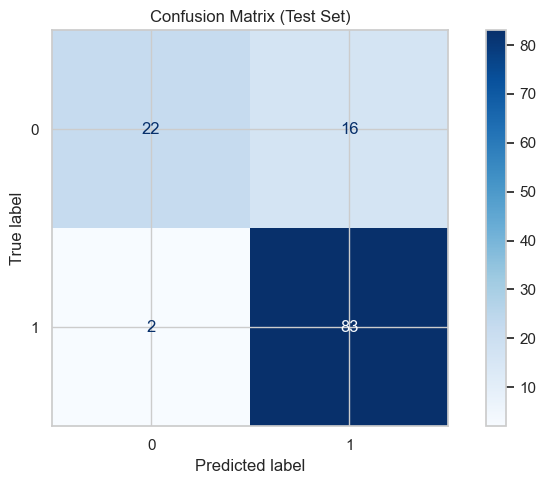

ROC-AUC: 0.8375


In [14]:
if not READY:
    print("Skipping evaluation: model not trained.")
else:
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("Test Accuracy:", round(acc, 4))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Confusion Matrix (Test Set)")
    save_fig("confusion_matrix.png")
    plt.show()

    # Optional ROC-AUC (only if binary and proba is available)
    if hasattr(clf, "predict_proba") and y.nunique() == 2:
        y_proba = clf.predict_proba(X_test)[:, 1]
        print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

In [15]:
if not READY:
    print("Skipping CV: dataset/model not ready.")
else:
    if y.nunique() == 2:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")
        print("CV Accuracy mean:", round(scores.mean(), 4), "| std:", round(scores.std(), 4))
    else:
        print("CV skipped: target is not binary.")

CV Accuracy mean: 0.803 | std: 0.0251


## Conclusion
- Report final test accuracy and confusion matrix observations (false positives / false negatives).
- Mention 1–2 EDA findings (LoanAmount distribution, Education vs outcome).
- Limitations: small dataset, possible class imbalance, simple baseline model.
- Improvements: try Decision Tree / Random Forest, hyperparameter tuning, threshold tuning.